# 01: MovieLens Interference Setup and EDA

This notebook starts the **interference and spillover effects** analysis. The causal problem is different from standard treatment-effect estimation because recommendation items compete with one another. If one movie is promoted into a visible slate position, another movie may lose visibility, attention, clicks, ratings, or watch time. That means an item's outcome may depend on its own treatment status and on the treatment assignments of nearby items.

The purpose of this first notebook is to understand the MovieLens data and prepare a clean foundation for later spillover notebooks. MovieLens lacks true production impressions and randomized promotion assignments, so this project will use MovieLens as a realistic preference dataset and then simulate recommendation slates, promotion assignments, and item competition structures.

## Dataset Field Guide

MovieLens 32M is distributed as four main CSV files inside `ml-32m.zip`.

### User-Movie Ratings

Each row is a user-movie rating event.

- `userId`: anonymized user identifier. A user can rate many movies.
- `movieId`: MovieLens movie identifier. This links to `movies.csv`, `links.csv`, and `tags.csv`.
- `rating`: explicit star rating on a 0.5 to 5.0 scale. In this project it is a preference signal used to simulate recommendation exposure and outcomes.
- `timestamp`: Unix timestamp for when the rating was created. This lets us study recency, user histories, and time ordering.

### Movie Metadata

Each row is a movie catalog item.

- `movieId`: MovieLens movie identifier.
- `title`: movie title, usually with a release year in parentheses.
- `genres`: pipe-delimited genre string such as `Comedy|Romance`. A movie can belong to multiple genres. We will use genres to create substitute groups because movies in similar genres plausibly compete for user attention.

### User Tags

Each row is a user-applied free-text tag for a movie.

- `userId`: anonymized user identifier for the tag event.
- `movieId`: tagged movie identifier.
- `tag`: user-generated text label such as an actor, theme, mood, franchise, or descriptive keyword.
- `timestamp`: Unix timestamp for when the tag was applied.

Tags are useful for richer item similarity, but they are sparse and noisy. In this first notebook we use them mainly for understanding catalog semantics.

### External Movie Identifiers

Each row maps a MovieLens movie to external identifiers.

- `movieId`: MovieLens movie identifier.
- `imdbId`: IMDb identifier.
- `tmdbId`: TMDb identifier.

External metadata is optional for the current project. The file is useful if we later want posters, richer genres, cast, crew, or production metadata.

## Causal Setup Preview

Later notebooks will convert this preference dataset into a simulated recommendation setting:

- A **slate** is a set of movies shown together to a user.
- A **treated item** is a movie promoted into a more visible position in the slate.
- A **spillover-exposed item** is another item in the same slate, especially a similar or substitutable movie.
- A **direct effect** measures what happens to the promoted item.
- An **indirect or spillover effect** measures what happens to competing items.
- A **total effect** combines promoted-item gains and displaced-item losses at the slate or cluster level.

This notebook prepares the data and estimands for those effects. It builds the data understanding and processed inputs needed to do that carefully.


## Project Framing

### What You Will Build

This project builds a spillover-aware causal workflow for recommendation slates. You will use MovieLens preference data to construct slates, simulate promotion assignment, define direct and neighbor exposure, estimate direct and indirect effects, and compare item-level conclusions with slate-level conclusions.

### How To Use This Project

Work through the notebooks in order. This first notebook creates the slate setting and explains why interference matters. Later notebooks map exposure, estimate cluster-randomized effects, decompose direct and indirect effects, and add advanced spillover models.

### Data Source And Scope

The project uses MovieLens ratings as a real preference source and builds a controlled simulated promotion setting on top of it. This is useful because MovieLens lacks randomized promotion experiments, while the simulated design allows the interference estimands and exposure mappings to be studied transparently.

<!-- dataset-experiment-context -->
## Dataset and Simulation Design Context

This project uses MovieLens 32M as a realistic user-item preference source. MovieLens contains ratings and movie metadata, but it lacks production recommendation impressions, randomized promotions, and observed slate outcomes.

Because the public data lack a real experiment, the project builds a transparent simulation. It constructs recommendation slates, selects lower-ranked focal movies, randomizes focal promotion at the slate level, and generates outcomes through an explicit competition model.

The simulated experiment is designed to teach interference. Promoting one item can increase that item's engagement while reducing attention for substitutes and neighboring items. The estimands are direct focal effects, spillover effects, and total slate value, so the project emphasizes experiment design and measurement logic as a teaching workflow.

**Role of this notebook.** This notebook turns MovieLens ratings into seed slates and explains why simulated slates are needed before interference can be studied.

<!-- mathematical-setup -->

## Mathematical Setup

Interference means one item’s treatment can affect another item’s outcome. Let \(D_i\) indicate whether item \(i\) is directly promoted and let \(S_i\) summarize exposure to promoted neighbors or competing items. The potential outcome is therefore indexed by both quantities:

$$
Y_i(d,s).
$$

The direct effect compares promotion status while holding spillover exposure fixed:

$$
\tau_{\text{direct}}(s)=\mathbb{E}[Y_i(1,s)-Y_i(0,s)].
$$

The EDA prepares the item, slate, and cluster structure needed to make these exposure definitions meaningful.


#### 1. Environment and Paths

This cell imports the libraries used for dataset inspection, plotting, and processed-data export. It also defines paths to the MovieLens zip file and the processed-data folder. The notebook reads directly from the zip file so we avoid permanently extracting a very large dataset into the repository.


In [1]:
# Set up environment and paths.
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "movieLens" / "ml-32m.zip").exists()
)

DATA_DIR = PROJECT_DIR / "data"
RAW_ZIP = DATA_DIR / "movieLens" / "ml-32m.zip"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"

RAW_ZIP.exists(), RAW_ZIP


### Inspect the MovieLens Archive

Before loading data, we inspect the zip archive itself. This confirms which files are present, how large they are, and whether the archive matches the standard MovieLens 32M layout. This is a useful first notebook habit because many downstream errors come from assuming a folder layout that differs from the local download.


In [2]:
with ZipFile(RAW_ZIP) as zf:
    archive_rows = []
    for info in zf.infolist():
        if not info.is_dir():
            archive_rows.append(
                {
                    "file": info.filename,
                    "compressed_mb": info.compress_size / 1_000_000,
                    "uncompressed_mb": info.file_size / 1_000_000,
                }
            )

archive_df = pd.DataFrame(archive_rows).sort_values("uncompressed_mb", ascending=False)
display(archive_df)


,file,compressed_mb,uncompressed_mb
4,ml-32m/ratings.csv,218.7859,877.0762
0,ml-32m/tags.csv,17.8637,72.3539
5,ml-32m/movies.csv,1.4578,4.2429
1,ml-32m/links.csv,0.8377,1.9507
2,ml-32m/README.txt,0.0037,0.0092
3,ml-32m/checksums.txt,0.0001,0.0002


The ratings file is by far the largest file, so the rest of the notebook treats it carefully. The movie metadata is small enough to load fully, while ratings need chunked reading and a deterministic user sample. That keeps the EDA reproducible without requiring the notebook to hold all 32 million interactions in memory.


#### 3. Load and Enrich the Movie Catalog

The movie catalog is the natural item table for the interference problem. This cell loads every movie, parses the release year from the title when available, splits the pipe-delimited genre string into a list, and creates a primary genre for simple grouping. Later notebooks can use these genre groups as item clusters where spillovers are most plausible.


In [3]:
# Load and enrich the movie catalog.
with ZipFile(RAW_ZIP) as zf:
    with zf.open("ml-32m/movies.csv") as file:
        movies = pd.read_csv(file)

movies = movies.assign(
    release_year=movies["title"].str.extract(r"\((\d{4})\)\s*$")[0].astype("float"),
    clean_title=movies["title"].str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True),
    genre_list=movies["genres"].fillna("(no genres listed)").str.split("|"),
)
movies["genre_count"] = movies["genre_list"].str.len()
movies["primary_genre"] = movies["genre_list"].str[0]

movie_summary = pd.DataFrame(
    {
        "metric": [
            "movies",
            "movies_with_release_year",
            "movies_without_genres",
            "distinct_primary_genres",
            "median_genres_per_movie",
        ],
        "value": [
            len(movies),
            int(movies["release_year"].notna().sum()),
            int((movies["genres"] == "(no genres listed)").sum()),
            movies["primary_genre"].nunique(),
            movies["genre_count"].median(),
        ],
    }
)

display(movie_summary)
display(movies.head())


,metric,value
0,movies,"87,585.0000"
1,movies_with_release_year,"86,968.0000"
2,movies_without_genres,"7,080.0000"
3,distinct_primary_genres,20.0000
4,median_genres_per_movie,1.0000


,movieId,title,genres,release_year,clean_title,genre_list,genre_count,primary_genre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"1,995.0000",Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",5,Adventure
1,2,Jumanji (1995),Adventure|Children|Fantasy,"1,995.0000",Jumanji,"[Adventure, Children, Fantasy]",3,Adventure
2,3,Grumpier Old Men (1995),Comedy|Romance,"1,995.0000",Grumpier Old Men,"[Comedy, Romance]",2,Comedy
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"1,995.0000",Waiting to Exhale,"[Comedy, Drama, Romance]",3,Comedy
4,5,Father of the Bride Part II (1995),Comedy,"1,995.0000",Father of the Bride Part II,[Comedy],1,Comedy


The catalog gives us a broad item universe and a simple substitute structure through genres. This is important because interference can vary strongly between movie groups. Promotion of one comedy is more likely to displace another comedy than an unrelated documentary, so genre-based grouping is a defensible first exposure model.


#### 4. Load a Tag Sample

Tags are optional for this first project stage, but they help us understand whether MovieLens has enough semantic information to support richer item similarity later. Because `tags.csv` is larger than the movie catalog and free-text tags can be messy, this cell reads a bounded sample and normalizes tags to lowercase for frequency checks.


In [4]:
# Load a tag sample.
TAG_SAMPLE_ROWS = 300_000

with ZipFile(RAW_ZIP) as zf:
    with zf.open("ml-32m/tags.csv") as file:
        tags_sample = pd.read_csv(file, nrows=TAG_SAMPLE_ROWS)

tags_sample = tags_sample.assign(
    tag_clean=tags_sample["tag"].astype("string").str.strip().str.lower(),
    tag_datetime=pd.to_datetime(tags_sample["timestamp"], unit="s"),
)

tag_summary = pd.DataFrame(
    {
        "metric": [
            "tag_rows_loaded",
            "unique_users_in_tag_sample",
            "unique_movies_in_tag_sample",
            "unique_clean_tags_in_sample",
            "tag_date_min",
            "tag_date_max",
        ],
        "value": [
            len(tags_sample),
            tags_sample["userId"].nunique(),
            tags_sample["movieId"].nunique(),
            tags_sample["tag_clean"].nunique(),
            tags_sample["tag_datetime"].min(),
            tags_sample["tag_datetime"].max(),
        ],
    }
)

display(tag_summary)
display(tags_sample.head())


,metric,value
0,tag_rows_loaded,300000
1,unique_users_in_tag_sample,3605
2,unique_movies_in_tag_sample,15914
3,unique_clean_tags_in_sample,28307
4,tag_date_min,2005-12-27 12:54:55
5,tag_date_max,2023-10-12 07:24:37


,userId,movieId,tag,timestamp,tag_clean,tag_datetime
0,22,26479,Kevin Kline,1583038886,kevin kline,2020-03-01 05:01:26
1,22,79592,misogyny,1581476297,misogyny,2020-02-12 02:58:17
2,22,247150,acrophobia,1622483469,acrophobia,2021-05-31 17:51:09
3,34,2174,music,1249808064,music,2009-08-09 08:54:24
4,34,2174,weird,1249808102,weird,2009-08-09 08:55:02


The tag sample confirms that MovieLens contains semantic item annotations beyond genres. Tags are user-generated and unevenly distributed, so they play a supporting descriptive role here. They are still useful evidence that richer similarity modeling is available if genre clusters become too coarse.


### Build a Deterministic Rating Sample

The ratings table has more than 32 million rows, so loading it all at once is unnecessary for exploratory work. Instead, this cell scans the ratings file in chunks and keeps all ratings for users whose `userId` is divisible by a fixed modulus. This creates a deterministic user-level sample: selected users keep their full rating histories, which is better for sequence and slate construction than randomly sampling isolated rows.

The scan also collects full-file summary statistics such as total row count, unique users, unique movies, rating distribution, and timestamp range.


In [5]:
# Build a deterministic rating sample.
USER_SAMPLE_MODULUS = 50
RATING_CHUNK_ROWS = 1_000_000

rating_chunks = []
all_user_ids = set()
all_movie_ids = set()
rating_value_counts = pd.Series(dtype="int64")
full_rating_rows = 0
timestamp_min = None
timestamp_max = None

rating_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

with ZipFile(RAW_ZIP) as zf:
    with zf.open("ml-32m/ratings.csv") as file:
        for chunk in pd.read_csv(file, chunksize=RATING_CHUNK_ROWS, dtype=rating_dtypes):
            full_rating_rows += len(chunk)
            all_user_ids.update(chunk["userId"].unique().tolist())
            all_movie_ids.update(chunk["movieId"].unique().tolist())
            rating_value_counts = rating_value_counts.add(chunk["rating"].value_counts(), fill_value=0)
            chunk_min = int(chunk["timestamp"].min())
            chunk_max = int(chunk["timestamp"].max())
            timestamp_min = chunk_min if timestamp_min is None else min(timestamp_min, chunk_min)
            timestamp_max = chunk_max if timestamp_max is None else max(timestamp_max, chunk_max)

            sampled_chunk = chunk.loc[chunk["userId"] % USER_SAMPLE_MODULUS == 0].copy()
            if not sampled_chunk.empty:
                rating_chunks.append(sampled_chunk)

ratings_sample = pd.concat(rating_chunks, ignore_index=True)
ratings_sample["rating_datetime"] = pd.to_datetime(ratings_sample["timestamp"], unit="s")
ratings_sample["rating_year"] = ratings_sample["rating_datetime"].dt.year
ratings_sample["liked"] = (ratings_sample["rating"] >= 4.0).astype("int8")

full_rating_summary = pd.DataFrame(
    {
        "metric": [
            "full_rating_rows_scanned",
            "full_unique_users",
            "full_unique_movies_with_ratings",
            "rating_timestamp_min",
            "rating_timestamp_max",
            "sample_user_modulus",
            "sample_rating_rows",
            "sample_unique_users",
            "sample_unique_movies",
        ],
        "value": [
            full_rating_rows,
            len(all_user_ids),
            len(all_movie_ids),
            pd.to_datetime(timestamp_min, unit="s"),
            pd.to_datetime(timestamp_max, unit="s"),
            USER_SAMPLE_MODULUS,
            len(ratings_sample),
            ratings_sample["userId"].nunique(),
            ratings_sample["movieId"].nunique(),
        ],
    }
)

display(full_rating_summary)
display(ratings_sample.head())


,metric,value
0,full_rating_rows_scanned,32000204
1,full_unique_users,200948
2,full_unique_movies_with_ratings,84432
3,rating_timestamp_min,1995-01-09 11:46:44
4,rating_timestamp_max,2023-10-13 02:29:07
5,sample_user_modulus,50
6,sample_rating_rows,617851
7,sample_unique_users,4018
8,sample_unique_movies,22313


,userId,movieId,rating,timestamp,rating_datetime,rating_year,liked
0,50,32,5.0000,1262076877,2009-12-29 08:54:37,2009,1
1,50,47,5.0000,1262077899,2009-12-29 09:11:39,2009,1
2,50,50,5.0000,1262076691,2009-12-29 08:51:31,2009,1
3,50,163,3.5000,1262076468,2009-12-29 08:47:48,2009,0
4,50,172,4.0000,1262076505,2009-12-29 08:48:25,2009,1


The sample keeps complete histories for a manageable set of users. That matters for this project because interference simulation needs realistic user-level candidate sets with connected rating histories. The full-file statistics also let us describe the original dataset honestly even though later modeling uses a smaller processed sample.


#### 6. Check Rating Scale and Preference Signal

This cell compares the full-file rating distribution collected during chunked loading with the sampled-user distribution. A close match is reassuring because it means the deterministic user sample preserves the basic preference signal.


In [6]:
full_rating_distribution = (
    rating_value_counts.sort_index()
    .rename_axis("rating")
    .reset_index(name="full_count")
)
full_rating_distribution["full_share"] = (
    full_rating_distribution["full_count"] / full_rating_distribution["full_count"].sum()
)

sample_rating_distribution = (
    ratings_sample["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="sample_count")
)
sample_rating_distribution["sample_share"] = (
    sample_rating_distribution["sample_count"] / sample_rating_distribution["sample_count"].sum()
)

rating_distribution = full_rating_distribution.merge(sample_rating_distribution, on="rating", how="left")
rating_distribution["share_difference"] = rating_distribution["sample_share"] - rating_distribution["full_share"]

display(rating_distribution)


,rating,full_count,full_share,sample_count,sample_share,share_difference
0,0.5000,"525,132.0000",0.0164,9200,0.0149,-0.0015
1,1.0000,"946,675.0000",0.0296,19406,0.0314,0.0018
2,1.5000,"531,063.0000",0.0166,9689,0.0157,-0.0009
3,2.0000,"2,028,622.0000",0.0634,41065,0.0665,0.0031
4,2.5000,"1,685,386.0000",0.0527,31052,0.0503,-0.0024
5,3.0000,"6,054,990.0000",0.1892,117188,0.1897,0.0005
6,3.5000,"4,290,105.0000",0.1341,80913,0.1310,-0.0031
7,4.0000,"8,367,654.0000",0.2615,161801,0.2619,0.0004
8,4.5000,"2,974,000.0000",0.0929,54857,0.0888,-0.0042
9,5.0000,"4,596,577.0000",0.1436,92680,0.1500,0.0064


The rating distribution is the first sanity check for the sampled data. If the sample had very different shares of high or low ratings, later simulated outcomes would inherit that distortion. Small differences are fine because the goal is a stable working dataset; the goal is a stable working dataset that preserves the main preference structure.


#### 7. Plot the Rating Distribution

The table above is precise, but the plot makes the rating scale easier to read. We show full-file and sampled-user shares side by side. The `liked` outcome used later is based on ratings of 4.0 or higher, so the mass around 4.0 and 5.0 is especially important.


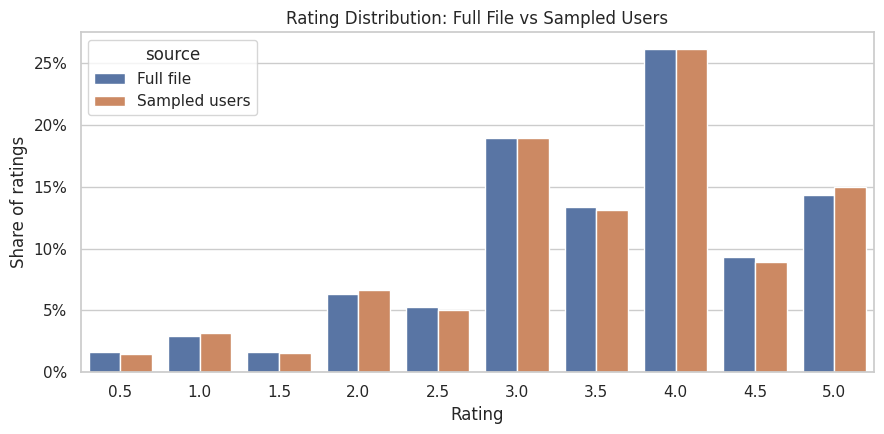

In [7]:
rating_plot_df = rating_distribution.melt(
    id_vars="rating",
    value_vars=["full_share", "sample_share"],
    var_name="source",
    value_name="share",
)
rating_plot_df["source"] = rating_plot_df["source"].map(
    {"full_share": "Full file", "sample_share": "Sampled users"}
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=rating_plot_df, x="rating", y="share", hue="source", ax=ax)
ax.set_title("Rating Distribution: Full File vs Sampled Users")
ax.set_xlabel("Rating")
ax.set_ylabel("Share of ratings")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()


The sampled-user distribution should track the full distribution closely. This makes the sampled ratings acceptable for EDA, user-history features, and initial slate construction. The concentration of positive ratings also reminds us that MovieLens ratings are explicit preference events generated by user behavior.


#### 8. Join Ratings to Movie Metadata

For interference analysis, ratings need movie metadata. We need item context so we can ask whether promoted movies displace similar movies. This cell joins the sampled ratings to movie metadata and checks whether any sampled ratings lack catalog information.


In [8]:
# Join ratings to movie metadata.
ratings_enriched = ratings_sample.merge(
    movies[
        [
            "movieId",
            "title",
            "clean_title",
            "genres",
            "primary_genre",
            "genre_count",
            "release_year",
        ]
    ],
    on="movieId",
    how="left",
)

join_quality = pd.DataFrame(
    {
        "metric": [
            "sample_rating_rows",
            "rows_missing_movie_title",
            "rows_missing_primary_genre",
            "distinct_primary_genres_in_ratings",
        ],
        "value": [
            len(ratings_enriched),
            int(ratings_enriched["title"].isna().sum()),
            int(ratings_enriched["primary_genre"].isna().sum()),
            ratings_enriched["primary_genre"].nunique(),
        ],
    }
)

display(join_quality)
display(ratings_enriched.head())


,metric,value
0,sample_rating_rows,617851
1,rows_missing_movie_title,0
2,rows_missing_primary_genre,0
3,distinct_primary_genres_in_ratings,20


,userId,movieId,rating,timestamp,rating_datetime,rating_year,liked,title,clean_title,genres,primary_genre,genre_count,release_year
0,50,32,5.0000,1262076877,2009-12-29 08:54:37,2009,1,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Twelve Monkeys (a.k.a. 12 Monkeys),Mystery|Sci-Fi|Thriller,Mystery,3,"1,995.0000"
1,50,47,5.0000,1262077899,2009-12-29 09:11:39,2009,1,Seven (a.k.a. Se7en) (1995),Seven (a.k.a. Se7en),Mystery|Thriller,Mystery,2,"1,995.0000"
2,50,50,5.0000,1262076691,2009-12-29 08:51:31,2009,1,"Usual Suspects, The (1995)","Usual Suspects, The",Crime|Mystery|Thriller,Crime,3,"1,995.0000"
3,50,163,3.5000,1262076468,2009-12-29 08:47:48,2009,0,Desperado (1995),Desperado,Action|Romance|Western,Action,3,"1,995.0000"
4,50,172,4.0000,1262076505,2009-12-29 08:48:25,2009,1,Johnny Mnemonic (1995),Johnny Mnemonic,Action|Sci-Fi|Thriller,Action,3,"1,995.0000"


The join quality check tells us whether MovieLens identifiers are internally consistent. A clean join means later notebooks can safely use movie genres, release years, and titles when defining substitute groups and explaining spillover mechanisms.


#### 9. User Activity Distribution

Interference simulation needs users with enough history to form realistic candidate slates. This cell summarizes how many ratings each sampled user has, their average rating, their share of high ratings, and the time span of their activity.


In [9]:
user_features = (
    ratings_enriched.groupby("userId")
    .agg(
        n_ratings=("rating", "size"),
        mean_rating=("rating", "mean"),
        liked_rate=("liked", "mean"),
        first_rating_time=("rating_datetime", "min"),
        last_rating_time=("rating_datetime", "max"),
        active_years=("rating_year", "nunique"),
        unique_primary_genres=("primary_genre", "nunique"),
    )
    .reset_index()
)
user_features["activity_span_days"] = (
    user_features["last_rating_time"] - user_features["first_rating_time"]
).dt.days

user_activity_summary = user_features[
    ["n_ratings", "mean_rating", "liked_rate", "active_years", "activity_span_days", "unique_primary_genres"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

display(user_activity_summary)
display(user_features.sort_values("n_ratings", ascending=False).head(10))


,count,mean,std,min,10%,25%,50%,75%,90%,max
n_ratings,"4,018.0000",153.7708,266.3372,20.0000,24.0000,36.0000,70.0000,162.0000,339.0000,"5,160.0000"
mean_rating,"4,018.0000",3.7075,0.4844,0.5500,3.1160,3.4134,3.7188,4.0156,4.3028,5.0000
liked_rate,"4,018.0000",0.5780,0.2041,0.0000,0.3018,0.4366,0.5815,0.7257,0.8462,1.0000
active_years,"4,018.0000",1.5271,1.6525,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,20.0000
activity_span_days,"4,018.0000",257.6847,809.0312,0.0000,0.0000,0.0000,0.0000,53.0000,701.3000,"8,396.0000"
unique_primary_genres,"4,018.0000",9.2086,3.0216,2.0000,6.0000,7.0000,9.0000,11.0000,14.0000,19.0000


,userId,n_ratings,mean_rating,liked_rate,first_rating_time,last_rating_time,active_years,unique_primary_genres,activity_span_days
1659,83000,5160,2.4058,0.0698,2002-08-19 19:48:36,2002-11-25 17:50:15,1,18,97
1640,82050,4681,3.3622,0.5954,2016-05-11 19:53:45,2023-10-06 02:48:47,8,19,2703
3185,159300,3714,3.0128,0.2130,2015-06-20 00:36:28,2023-10-10 00:38:25,9,19,3034
268,13450,3212,3.2425,0.2313,2015-04-28 21:23:47,2015-10-17 12:16:39,1,19,171
1059,53000,2937,3.8413,0.5788,2014-12-18 23:45:37,2021-10-23 00:32:59,5,19,2500
1334,66750,2740,3.6943,0.5544,2005-09-05 19:46:49,2023-06-24 03:41:52,10,19,6500
185,9300,2587,3.3761,0.3545,2005-08-28 08:22:39,2023-09-11 15:50:15,18,18,6588
2126,106350,2378,3.8425,0.6514,2001-06-20 21:31:57,2023-02-18 21:12:27,15,18,7912
1810,90550,2357,3.4913,0.3818,2000-04-06 22:40:10,2021-10-27 23:42:19,17,17,7874
1030,51550,2288,3.0590,0.4274,2016-03-13 17:39:09,2023-10-06 18:14:38,7,18,2763


The user activity distribution tells us how many users can support slate construction. Users with very few ratings are less useful because we cannot build a credible set of competing candidate items for them. Users with broader genre histories are especially useful because they create slates with both substitutes and non-substitutes.


#### 10. Plot User Activity and Rating Tendencies

This cell visualizes user heterogeneity. The left plot shows the long-tailed number of ratings per sampled user. The right plot shows the distribution of each user's average rating. Both matter because recommendation simulations should account for heavy users and naturally generous or strict raters.


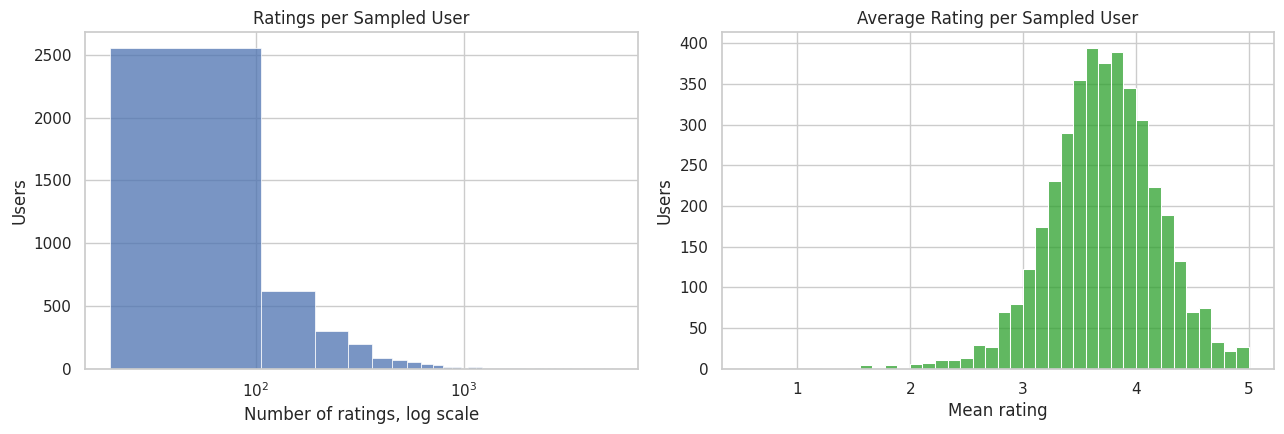

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(user_features["n_ratings"], bins=60, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Ratings per Sampled User")
axes[0].set_xlabel("Number of ratings, log scale")
axes[0].set_ylabel("Users")

sns.histplot(user_features["mean_rating"], bins=40, ax=axes[1], color="tab:green")
axes[1].set_title("Average Rating per Sampled User")
axes[1].set_xlabel("Mean rating")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()


The log scale is intentional because user activity is usually very skewed. That skew matters for interference: a small number of very active users may create many plausible slates, while less active users may only support a few. Later simulations should avoid letting the heaviest users dominate all estimates.


### Item Popularity and Quality Signals

This cell creates item-level features from the sampled ratings. These features describe how often each movie appears, its average rating, and its high-rating rate. Popularity is important for simulated ranking because promoted items are rarely assigned from a uniform catalog; recommendation systems tend to draw from relevant and popular candidates.


In [11]:
# Prepare item popularity and quality signals.
item_features = (
    ratings_enriched.groupby("movieId")
    .agg(
        sample_rating_count=("rating", "size"),
        sample_mean_rating=("rating", "mean"),
        sample_liked_rate=("liked", "mean"),
        first_sample_rating_time=("rating_datetime", "min"),
        last_sample_rating_time=("rating_datetime", "max"),
    )
    .reset_index()
    .merge(movies, on="movieId", how="left")
)

item_features["popularity_bucket"] = pd.qcut(
    item_features["sample_rating_count"].rank(method="first"),
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
)

top_items = item_features.sort_values("sample_rating_count", ascending=False).head(15)[
    ["movieId", "title", "primary_genre", "sample_rating_count", "sample_mean_rating", "sample_liked_rate"]
]

item_summary = item_features[
    ["sample_rating_count", "sample_mean_rating", "sample_liked_rate", "genre_count"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

display(item_summary)
display(top_items)


,count,mean,std,min,10%,25%,50%,75%,90%,max
sample_rating_count,"22,313.0000",27.6902,95.9410,1.0000,1.0000,1.0000,2.0000,12.0000,56.0000,"2,031.0000"
sample_mean_rating,"22,313.0000",3.2312,0.9839,0.5000,2.0000,2.7867,3.4000,3.8571,4.2500,5.0000
sample_liked_rate,"22,313.0000",0.3893,0.3626,0.0000,0.0000,0.0000,0.3333,0.6410,1.0000,1.0000
genre_count,"22,313.0000",2.0419,1.0570,1.0000,1.0000,1.0000,2.0000,3.0000,3.0000,10.0000


,movieId,title,primary_genre,sample_rating_count,sample_mean_rating,sample_liked_rate
306,318,"Shawshank Redemption, The (1994)",Crime,2031,4.4094,0.8612
285,296,Pulp Fiction (1994),Comedy,1965,4.1883,0.7913
343,356,Forrest Gump (1994),Comedy,1952,4.0666,0.7208
2371,2571,"Matrix, The (1999)",Action,1865,4.1550,0.7609
573,593,"Silence of the Lambs, The (1991)",Crime,1792,4.1083,0.7695
250,260,Star Wars: Episode IV - A New Hope (1977),Action,1710,4.0854,0.7386
2746,2959,Fight Club (1999),Action,1538,4.2048,0.7874
1103,1196,Star Wars: Episode V - The Empire Strikes Back...,Action,1446,4.0992,0.7510
464,480,Jurassic Park (1993),Action,1443,3.7290,0.5703
511,527,Schindler's List (1993),Drama,1430,4.2374,0.8070


The top movies reveal the attention distribution that a simulated recommender would inherit. If we promote already-popular movies, displacement may mostly affect other popular substitutes. If we promote niche movies, spillovers may look different. This is why popularity buckets are saved as item features.


#### 12. Plot the Item Popularity Long Tail

Recommendation catalogs usually have a long tail: a few items receive many interactions, while most items receive few. This plot checks whether the MovieLens sample has that shape. A long tail is useful here because spillovers can be studied across popular, medium, and niche items.


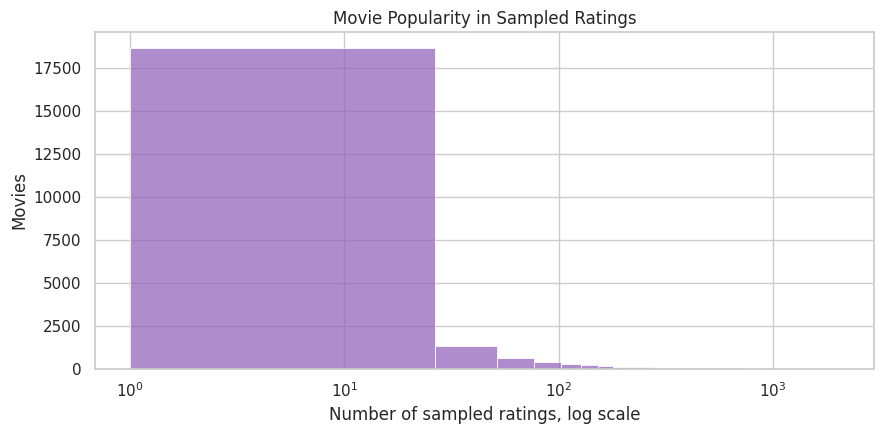

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(item_features["sample_rating_count"], bins=80, ax=ax, color="tab:purple")
ax.set_xscale("log")
ax.set_title("Movie Popularity in Sampled Ratings")
ax.set_xlabel("Number of sampled ratings, log scale")
ax.set_ylabel("Movies")
plt.tight_layout()
plt.show()


The long-tail pattern supports the simulation plan. Interference is partly about scarce attention, and scarce attention is most interesting when items vary widely in baseline popularity. This also gives later notebooks a reason to report effects separately by item popularity tier.


### Genre Coverage and Substitute Groups

Genres are the first approximation to item clusters. This cell explodes the multi-genre movie table so each movie contributes to every genre it belongs to, then computes catalog size, rating volume, average rating, and liked rate by genre.


In [13]:
movie_genres = movies[["movieId", "genre_list"]].explode("genre_list").rename(columns={"genre_list": "genre"})

rating_genres = ratings_sample[["movieId", "rating", "liked"]].merge(movie_genres, on="movieId", how="left")

genre_summary = (
    rating_genres.groupby("genre")
    .agg(
        sampled_rating_rows=("rating", "size"),
        unique_movies=("movieId", "nunique"),
        mean_rating=("rating", "mean"),
        liked_rate=("liked", "mean"),
    )
    .reset_index()
    .sort_values("sampled_rating_rows", ascending=False)
)

display(genre_summary)


,genre,sampled_rating_rows,unique_movies,mean_rating,liked_rate
8,Drama,271190,9867,3.6791,0.5567
5,Comedy,215975,7010,3.4352,0.4565
1,Action,186192,3443,3.4850,0.4668
17,Thriller,167555,4070,3.5485,0.4938
2,Adventure,145711,2042,3.5298,0.4885
16,Sci-Fi,111123,1878,3.5124,0.4816
15,Romance,107165,3354,3.5506,0.5035
6,Crime,104853,2332,3.6946,0.5596
9,Fantasy,70853,1422,3.5189,0.4870
4,Children,51351,1239,3.4301,0.4579


The genre summary gives the first map of possible spillover neighborhoods. Large genres such as drama or comedy can support many within-genre substitute comparisons. Smaller genres may need to be combined or treated cautiously because sparse clusters can create noisy spillover estimates.


#### 14. Plot Rating Volume by Genre

This visualization highlights which genres dominate the sampled preference data. For interference modeling, this helps decide where simulated slates will have enough similar items to create meaningful within-cluster competition.


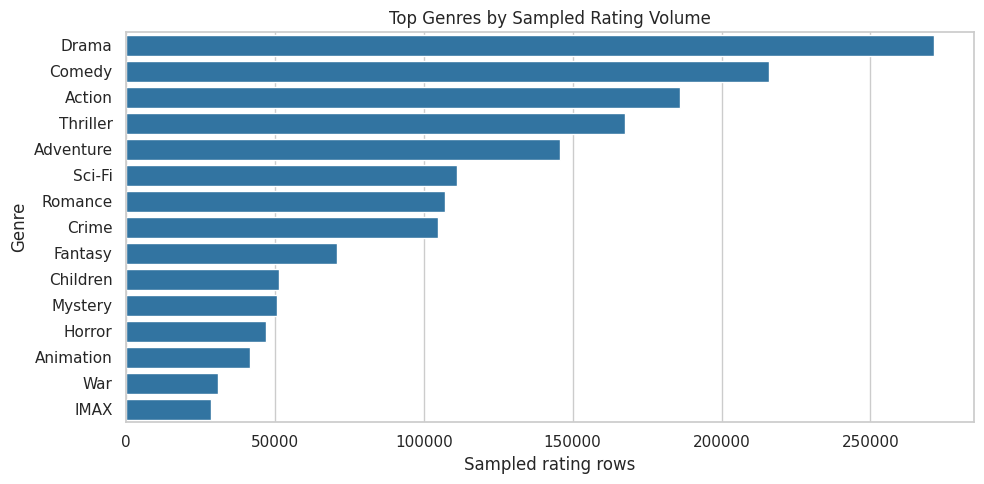

In [14]:
top_genres = genre_summary.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_genres, x="sampled_rating_rows", y="genre", ax=ax, color="tab:blue")
ax.set_title("Top Genres by Sampled Rating Volume")
ax.set_xlabel("Sampled rating rows")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()


The largest genres are natural starting points for substitute clusters. Later, when we simulate a promoted item, we can define spillover exposure as the number or share of same-genre items promoted nearby in the same slate. That turns genre EDA into a causal exposure model.


#### 15. Time Coverage in the Rating Sample

MovieLens spans many years. This cell summarizes rating volume over calendar time so we can see whether the sample covers the same broad period as the full file. Time matters because user preferences, catalog composition, and platform behavior can all drift.


In [15]:
yearly_activity = (
    ratings_sample.groupby("rating_year")
    .agg(
        rating_rows=("rating", "size"),
        users=("userId", "nunique"),
        movies=("movieId", "nunique"),
        mean_rating=("rating", "mean"),
        liked_rate=("liked", "mean"),
    )
    .reset_index()
)

display(yearly_activity.head())
display(yearly_activity.tail())


,rating_year,rating_rows,users,movies,mean_rating,liked_rate
0,1996,31909,510,1030,3.5553,0.4914
1,1997,12671,225,1161,3.5889,0.5097
2,1998,6167,82,1396,3.6142,0.5821
3,1999,21873,197,2177,3.6783,0.6207
4,2000,40933,299,3095,3.5898,0.5754


,rating_year,rating_rows,users,movies,mean_rating,liked_rate
23,2019,28206,247,5998,3.6410,0.5284
24,2020,31039,265,7148,3.5423,0.4982
25,2021,22974,241,5981,3.6466,0.5339
26,2022,18050,215,5139,3.7061,0.5532
27,2023,20494,186,5242,3.6596,0.5222


The yearly table checks temporal breadth and gives a first look at drift. Later simulations should avoid accidentally mixing very old and very recent behavior without acknowledging it.


#### 16. Plot Yearly Rating Activity

The plot makes the time trend easier to see than the table. We show sampled rating volume and average rating by year. This helps identify whether a small number of years dominate the sample.


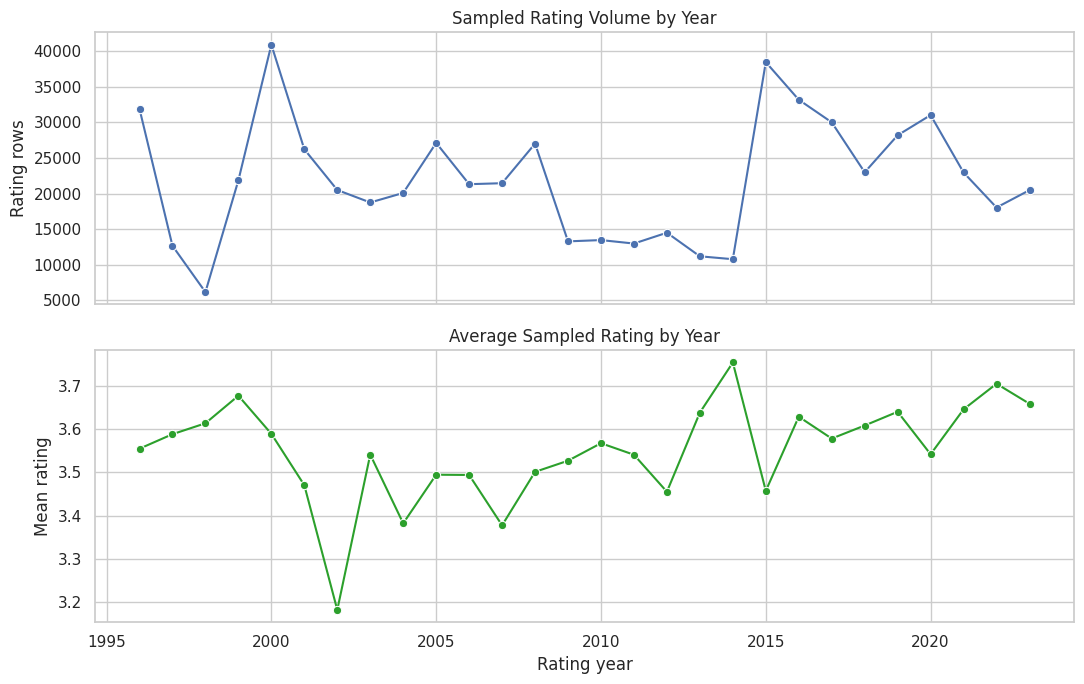

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

sns.lineplot(data=yearly_activity, x="rating_year", y="rating_rows", marker="o", ax=axes[0])
axes[0].set_title("Sampled Rating Volume by Year")
axes[0].set_ylabel("Rating rows")
axes[0].set_xlabel("")

sns.lineplot(data=yearly_activity, x="rating_year", y="mean_rating", marker="o", ax=axes[1], color="tab:green")
axes[1].set_title("Average Sampled Rating by Year")
axes[1].set_ylabel("Mean rating")
axes[1].set_xlabel("Rating year")

plt.tight_layout()
plt.show()


The time trend is useful for deciding whether future notebooks should include calendar controls. Even in a simulation project, realistic time structure matters because old and new catalog items may have different popularity and competition patterns.


#### 17. Top Tags in the Sample

This cell inspects the most common cleaned tags. Tags often capture actors, franchises, moods, themes, and other semantics that genres miss. Seeing them helps explain how the project could be extended beyond genre-level spillovers.


In [17]:
top_tags = (
    tags_sample.dropna(subset=["tag_clean"])
    .groupby("tag_clean")
    .agg(tag_rows=("tag_clean", "size"), users=("userId", "nunique"), movies=("movieId", "nunique"))
    .reset_index()
    .sort_values("tag_rows", ascending=False)
    .head(25)
)

display(top_tags)


,tag_clean,tag_rows,users,movies
22173,sci-fi,2562,667,474
2051,atmospheric,2418,503,536
609,action,2354,461,686
5411,comedy,2204,503,887
9942,funny,2075,489,774
27109,visually appealing,1628,482,295
24606,surreal,1596,488,345
21607,romance,1469,351,654
26232,twist ending,1459,482,224
25439,thought-provoking,1391,469,245


The tag sample suggests richer semantic neighborhoods are possible. For example, two movies in different genres might still compete if they share an actor, franchise, mood, or theme. The first version of the project will stay with genres for clarity, but tags are a credible future refinement.


### Define an Interference-Ready Item Table

This cell creates the item table that later notebooks can reuse. It combines catalog metadata with sampled popularity and preference features. It also defines `spillover_cluster`, a first-pass substitute group based on primary genre. This is intentionally simple and explainable.


In [18]:
# Define an interference-Ready item table.
interference_items = item_features.assign(
    spillover_cluster=item_features["primary_genre"].fillna("unknown"),
    is_broad_release_year=item_features["release_year"].notna().astype("int8"),
)[
    [
        "movieId",
        "title",
        "clean_title",
        "genres",
        "primary_genre",
        "spillover_cluster",
        "release_year",
        "genre_count",
        "sample_rating_count",
        "sample_mean_rating",
        "sample_liked_rate",
        "popularity_bucket",
    ]
].copy()

cluster_readiness = (
    interference_items.groupby("spillover_cluster")
    .agg(
        movies=("movieId", "nunique"),
        sampled_ratings=("sample_rating_count", "sum"),
        mean_item_rating=("sample_mean_rating", "mean"),
    )
    .reset_index()
    .sort_values("sampled_ratings", ascending=False)
)

display(cluster_readiness.head(20))


,spillover_cluster,movies,sampled_ratings,mean_item_rating
1,Action,3443,186192,3.1305
5,Comedy,5432,139545,3.1890
8,Drama,5580,116649,3.3018
2,Adventure,1116,61465,3.1763
6,Crime,1196,44116,3.4327
11,Horror,1306,16833,2.8955
3,Animation,706,14465,3.2919
4,Children,427,10747,3.1775
7,Documentary,1372,6739,3.3269
14,Mystery,124,6230,3.4562


The `spillover_cluster` column is the bridge from EDA to causal design. In later notebooks, a movie's potential outcomes can depend on its own promotion and on the promotion intensity among other movies in the same cluster or slate.


### Build a Seed Dataset for Simulated Slates

MovieLens lacks records of which movies were shown together, so later notebooks need to simulate slates. This cell creates a seed table by selecting active users and taking a bounded set of their recent, highly rated movies. Each user's seed slate is a realistic candidate set that later notebooks can rank, promote, and use for spillover exposure construction.; it is a realistic candidate set that later notebooks can rank, promote, and use for spillover exposure construction.


In [19]:
# Build a seed dataset for simulated slates.
MIN_USER_RATINGS_FOR_SLATE = 20
SLATE_SIZE = 12
MAX_SEED_USERS = 3_000
RECENT_POOL_SIZE = 50

eligible_users = (
    user_features.query("n_ratings >= @MIN_USER_RATINGS_FOR_SLATE")
    .sort_values(["n_ratings", "unique_primary_genres"], ascending=False)
    .head(MAX_SEED_USERS)["userId"]
)

recent_pool = (
    ratings_enriched.loc[ratings_enriched["userId"].isin(eligible_users)]
    .sort_values(["userId", "rating_datetime"], ascending=[True, False])
    .assign(recent_rank=lambda df: df.groupby("userId").cumcount() + 1)
    .query("recent_rank <= @RECENT_POOL_SIZE")
)

slate_seed = (
    recent_pool.sort_values(["userId", "rating", "rating_datetime"], ascending=[True, False, False])
    .groupby("userId", group_keys=False)
    .head(SLATE_SIZE)
    .copy()
)

slate_seed["slate_id"] = "user_" + slate_seed["userId"].astype(str) + "_seed"
slate_seed["slate_position_seed"] = slate_seed.groupby("userId").cumcount() + 1
slate_seed["observed_relevance"] = slate_seed["rating"]
slate_seed["high_relevance"] = (slate_seed["rating"] >= 4.0).astype("int8")
slate_seed["spillover_cluster"] = slate_seed["primary_genre"].fillna("unknown")

complete_slate_ids = (
    slate_seed.groupby("slate_id").size().loc[lambda size: size == SLATE_SIZE].index
)
slate_seed = slate_seed.loc[slate_seed["slate_id"].isin(complete_slate_ids)].copy()

slate_seed = slate_seed[
    [
        "slate_id",
        "userId",
        "movieId",
        "title",
        "genres",
        "primary_genre",
        "spillover_cluster",
        "slate_position_seed",
        "observed_relevance",
        "high_relevance",
        "rating_datetime",
        "rating_year",
    ]
]

slate_seed_summary = pd.DataFrame(
    {
        "metric": [
            "eligible_users_considered",
            "complete_seed_slates",
            "rows_in_seed_slate_table",
            "slate_size",
            "unique_movies_in_seed_slates",
            "unique_spillover_clusters",
            "mean_high_relevance_rate",
        ],
        "value": [
            len(eligible_users),
            slate_seed["slate_id"].nunique(),
            len(slate_seed),
            SLATE_SIZE,
            slate_seed["movieId"].nunique(),
            slate_seed["spillover_cluster"].nunique(),
            slate_seed["high_relevance"].mean(),
        ],
    }
)

display(slate_seed_summary)
display(slate_seed.head(15))


,metric,value
0,eligible_users_considered,"3,000.0000"
1,complete_seed_slates,"3,000.0000"
2,rows_in_seed_slate_table,"36,000.0000"
3,slate_size,12.0000
4,unique_movies_in_seed_slates,"5,668.0000"
5,unique_spillover_clusters,19.0000
6,mean_high_relevance_rate,0.9596


,slate_id,userId,movieId,title,genres,primary_genre,spillover_cluster,slate_position_seed,observed_relevance,high_relevance,rating_datetime,rating_year
74,user_50_seed,50,4027,"O Brother, Where Art Thou? (2000)",Adventure|Comedy|Crime,Adventure,Adventure,1,5.0000,1,2009-12-31 06:58:12,2009
27,user_50_seed,50,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,Action,Action,2,5.0000,1,2009-12-29 09:12:16,2009
1,user_50_seed,50,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,Mystery,3,5.0000,1,2009-12-29 09:11:39,2009
101,user_50_seed,50,52435,How the Grinch Stole Christmas! (1966),Animation|Comedy|Fantasy|Musical,Animation,Animation,4,5.0000,1,2009-12-29 09:10:49,2009
36,user_50_seed,50,1214,Alien (1979),Horror|Sci-Fi,Horror,Horror,5,5.0000,1,2009-12-29 09:09:28,2009
49,user_50_seed,50,1288,This Is Spinal Tap (1984),Comedy,Comedy,Comedy,6,5.0000,1,2009-12-29 09:09:18,2009
11,user_50_seed,50,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,Crime,Crime,7,5.0000,1,2009-12-29 09:08:00,2009
25,user_50_seed,50,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,Adventure,Adventure,8,5.0000,1,2009-12-29 09:05:51,2009
67,user_50_seed,50,2959,Fight Club (1999),Action|Crime|Drama|Thriller,Action,Action,9,5.0000,1,2009-12-29 09:05:21,2009
52,user_50_seed,50,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,Crime,Crime,10,5.0000,1,2009-12-29 09:04:30,2009


The seed slate table is the key handoff from this notebook. It gives later notebooks user-specific candidate sets with item metadata and relevance labels. The next notebook can now focus on exposure mapping: which items are promoted, which same-cluster items are spillover-exposed, and how promotion changes simulated slate outcomes.


In [ ]:
#| include: false
# Save processed inputs.
ratings_output = PROCESSED_DIR / "movielens_interference_ratings_sample.parquet"
items_output = PROCESSED_DIR / "movielens_interference_items.parquet"
users_output = PROCESSED_DIR / "movielens_interference_user_features.parquet"
slates_output = PROCESSED_DIR / "movielens_interference_slate_seed.parquet"
readiness_output = PROCESSED_DIR / "movielens_interference_setup_readiness.csv"

ratings_enriched.to_parquet(ratings_output, index=False)
interference_items.to_parquet(items_output, index=False)
user_features.to_parquet(users_output, index=False)
slate_seed.to_parquet(slates_output, index=False)

readiness_checks = pd.DataFrame(
    [
        {
            "check": "raw_zip_found",
            "value": bool(RAW_ZIP.exists()),
            "notes": "MovieLens zip file is available locally.",
        },
        {
            "check": "ratings_sample_rows",
            "value": len(ratings_enriched),
            "notes": "Sample contains complete histories for selected users.",
        },
        {
            "check": "sample_unique_users",
            "value": ratings_enriched["userId"].nunique(),
            "notes": "Users available for user-level slate simulation.",
        },
        {
            "check": "sample_unique_movies",
            "value": ratings_enriched["movieId"].nunique(),
            "notes": "Movies available for item-level spillover analysis.",
        },
        {
            "check": "complete_seed_slates",
            "value": slate_seed["slate_id"].nunique(),
            "notes": "Complete seed slates available for exposure simulation.",
        },
        {
            "check": "seed_slate_rows",
            "value": len(slate_seed),
            "notes": "Rows in the slate seed table; should equal complete slates times slate size.",
        },
        {
            "check": "spillover_clusters",
            "value": interference_items["spillover_cluster"].nunique(),
            "notes": "Initial substitute clusters based on primary genre.",
        },
    ]
)
readiness_checks.to_csv(readiness_output, index=False)

saved_files = pd.DataFrame(
    {
        "artifact": [
            "ratings_sample",
            "interference_items",
            "user_features",
            "slate_seed",
            "readiness_checks",
        ],
        "path": [
            str(ratings_output),
            str(items_output),
            str(users_output),
            str(slates_output),
            str(readiness_output),
        ],
    }
)

display(readiness_checks)
display(saved_files)


The processed files make the interference project reproducible and modular. The important output is the seed slate table because it gives the next notebook a realistic starting point for simulating promotion assignments and spillover exposure. The user and item feature tables provide adjustment and segmentation variables.


### Takeaways and Next Step

This notebook established the foundation for an interference/spillover analysis using MovieLens:

- MovieLens has strong user-item preference data but no true impression logs, so the causal design must be simulated.
- Ratings provide a preference/relevance signal, while genres provide a transparent first substitute-cluster definition.
- The sampled-user strategy keeps complete histories for selected users, which is more useful than isolated row sampling.
- The seed slate table creates realistic user-specific candidate sets for later promotion and spillover simulations.
- The next notebook should define exposure mappings: direct promotion, same-slate spillover exposure, same-cluster spillover exposure, and slate-level outcome construction.
